# CE49X Lab 2: Is Wave Energy Worth the Investment?
## A Financial Feasibility Comparison of Renewable Energy in Perth, Australia

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

## Deliverables

Your notebook must include the following:

### 1. Wave Energy Analysis (from the dataset)
- Load and explore the `WEC_Perth_49.csv` dataset
- Compute statistics on farm power output (mean, min, max, standard deviation)
- Estimate a **capacity factor** for wave energy in Perth based on the data (you'll need to assume a rated capacity per WEC — research and justify your choice)

### 2. Competing Technologies
- Choose **at least two** other renewable energy technologies to compare against wave energy (e.g., solar PV, onshore wind, offshore wind, tidal, biomass)
- Research and cite the following for **each** technology (including wave):
  - Capital cost (CAPEX) per kW installed
  - Annual operating cost (OPEX) per kW
  - Capacity factor specific to the Perth region
  - Expected project lifetime
- **Cite your sources.** Use data from reputable organizations (e.g., IRENA, IEA, CSIRO, NREL, Lazard).

### 3. Financial Comparison
- Calculate the **Levelized Cost of Energy (LCOE)** for each technology
- Calculate **at least one additional financial metric** of your choice (e.g., NPV, payback period, internal rate of return, cost per annual MWh)
- Choose an appropriate **discount rate** and justify it

### 4. Visualization
- Create **at least two plots** that clearly communicate your comparison
- Plots should be publication-quality: labeled axes, title, legend, grid

### 5. Recommendation
- Based on your analysis, write a short recommendation (1-2 paragraphs):
  - Which technology (or mix) should Perth invest in?
  - Under what conditions could wave energy become competitive?
  - What factors does your financial model **not** capture?

## Hints

- **LCOE formula:**

$$\text{LCOE} = \frac{\text{Total Discounted Costs}}{\text{Total Discounted Energy}} = \frac{\text{CAPEX} + \sum_{t=1}^{N} \frac{\text{OPEX}_t}{(1+r)^t}}{\sum_{t=1}^{N} \frac{E_t}{(1+r)^t}}$$

  where $r$ is the discount rate, $N$ is the project lifetime, and $E_t$ is annual energy production in MWh.

- **Annual energy production:** $E = \text{Capacity (kW)} \times \text{Capacity Factor} \times 8760 \text{ hours/year}$

- The dataset gives power in **Watts**. Be careful with unit conversions.

- Think about what the dataset's `Total_Power` column actually represents and how it relates to the rated capacity of a real WEC device.

## Grading

| Component | Weight |
|-----------|--------|
| Wave energy analysis (dataset exploration, capacity factor) | 20% |
| Research quality (cost data, sources, justification) | 25% |
| Financial calculations (LCOE + additional metric) | 25% |
| Visualizations (clarity, quality) | 15% |
| Recommendation (insight, completeness) | 15% |

## Submission

1. Complete your work in **this notebook** on your own fork of the course repository.
2. Make sure your notebook **runs top-to-bottom without errors** before submitting.
3. Commit and push your completed notebook to your fork.
4. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

## 1. Wave Energy Analysis

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the WEC Perth dataset
df_wec = pd.read_csv('WEC_Perth_49.csv')

# ===== DATASET EXPLORATION =====
print("="*70)
print("DATASET EXPLORATION: WEC_Perth_49.csv")
print("="*70)
print(f"\nDataset shape: {df_wec.shape}")
print(f"Columns: {df_wec.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_wec.head(10))
print(f"\nData types:")
print(df_wec.dtypes)
print(f"\nBasic statistics:")
print(df_wec.describe())

# ===== FARM POWER STATISTICS =====
print("\n" + "="*70)
print("FARM POWER OUTPUT STATISTICS")
print("="*70)

mean_power = df_wec['Total_Power'].mean()
min_power = df_wec['Total_Power'].min()
max_power = df_wec['Total_Power'].max()
std_power = df_wec['Total_Power'].std()
median_power = df_wec['Total_Power'].median()

print(f"\nTotal Farm Power (Watts):")
print(f"  • Mean:   {mean_power:,.2f} W  ({mean_power/1e6:.2f} MW)")
print(f"  • Min:    {min_power:,.2f} W  ({min_power/1e6:.2f} MW)")
print(f"  • Max:    {max_power:,.2f} W  ({max_power/1e6:.2f} MW)")
print(f"  • Median: {median_power:,.2f} W  ({median_power/1e6:.2f} MW)")
print(f"  • Std:    {std_power:,.2f} W  ({std_power/1e6:.2f} MW)")

# ===== CAPACITY FACTOR CALCULATION =====
print("\n" + "="*70)
print("CAPACITY FACTOR ESTIMATION")
print("="*70)

# According to the dataset metadata, there are 49 WEC devices (wave energy converters)
n_wec = 49

# Research justification for rated capacity per WEC:
# The Pelamis P2 is a reference point (750 kW rated), but considering Perth's wave climate
# and typical device scaling, a 500 kW rated capacity per device is reasonable.
# Sources: IRENA (2020) Ocean Energy Technology Brief; Pelamis Wave Power specifications;
# CSIRO Marine and Atmospheric Research (Perth wave energy potential)

rated_power_per_wec = 500000  # Watts (500 kW per device)
total_rated_capacity = n_wec * rated_power_per_wec  # Watts

print(f"\nAssumptions:")
print(f"  • Number of WEC devices: {n_wec}")
print(f"  • Rated power per device: {rated_power_per_wec/1000:.0f} kW")
print(f"  • Total rated capacity: {total_rated_capacity/1e6:.1f} MW")

print(f"\nJustification:")
print(f"  - Pelamis P2 reference device: 750 kW rated capacity")
print(f"  - Perth's wave climate moderate relative to other regions")
print(f"  - 500 kW represents technology maturity and conservative design")
print(f"  - Sources: IRENA Ocean Technology Brief 2020; Pelamis specifications")

# Capacity factor = Mean annual power / Rated power
capacity_factor_wave = mean_power / total_rated_capacity

print(f"\n{'-'*70}")
print(f"CAPACITY FACTOR CALCULATION:")
print(f"  CF = Mean Power / Rated Capacity")
print(f"  CF = {mean_power:,.0f} W / {total_rated_capacity:,.0f} W")
print(f"  CF = {capacity_factor_wave:.4f} ({capacity_factor_wave*100:.2f}%)")
print(f"{'-'*70}")

# Interpretation
print(f"\nInterpretation:")
if capacity_factor_wave < 0.25:
    print(f"  Low capacity factor (~{capacity_factor_wave*100:.1f}%) typical for wave energy")
elif capacity_factor_wave < 0.35:
    print(f"  Moderate capacity factor (~{capacity_factor_wave*100:.1f}%), reasonable for Perth")
else:
    print(f"  Good capacity factor (~{capacity_factor_wave*100:.1f}%)")
print(f"  This means the farm operates at ~{capacity_factor_wave*100:.1f}% of its rated capacity on average")
print(f"  Reference: Onshore wind typical CF 25-35%, Solar 15-25%, Wave 20-40% depending on site")

print("\n" + "="*70)


DATASET EXPLORATION: WEC_Perth_49.csv

Dataset shape: (36043, 149)
Columns: ['X1', 'Y1', 'X2', 'Y2', 'X3', 'Y3', 'X4', 'Y4', 'X5', 'Y5', 'X6', 'Y6', 'X7', 'Y7', 'X8', 'Y8', 'X9', 'Y9', 'X10', 'Y10', 'X11', 'Y11', 'X12', 'Y12', 'X13', 'Y13', 'X14', 'Y14', 'X15', 'Y15', 'X16', 'Y16', 'X17', 'Y17', 'X18', 'Y18', 'X19', 'Y19', 'X20', 'Y20', 'X21', 'Y21', 'X22', 'Y22', 'X23', 'Y23', 'X24', 'Y24', 'X25', 'Y25', 'X26', 'Y26', 'X27', 'Y27', 'X28', 'Y28', 'X29', 'Y29', 'X30', 'Y30', 'X31', 'Y31', 'X32', 'Y32', 'X33', 'Y33', 'X34', 'Y34', 'X35', 'Y35', 'X36', 'Y36', 'X37', 'Y37', 'X38', 'Y38', 'X39', 'Y39', 'X40', 'Y40', 'X41', 'Y41', 'X42', 'Y42', 'X43', 'Y43', 'X44', 'Y44', 'X45', 'Y45', 'X46', 'Y46', 'X47', 'Y47', 'X48', 'Y48', 'X49', 'Y49', 'Power1', 'Power2', 'Power3', 'Power4', 'Power5', 'Power6', 'Power7', 'Power8', 'Power9', 'Power10', 'Power11', 'Power12', 'Power13', 'Power14', 'Power15', 'Power16', 'Power17', 'Power18', 'Power19', 'Power20', 'Power21', 'Power22', 'Power23', 'Power24', 

## 2. Competing Technologies

In [28]:

# Define technologies data with research-based parameters
# This section compares Wave Energy against Solar PV and Biomass

import pandas as pd

print("="*80)
print("TASK 2: COMPETING TECHNOLOGIES - RESEARCH & COMPARISON")
print("="*80)

# ===== TECHNOLOGY 1: WAVE ENERGY (from Task 1 calculation) =====
print("\n" + "-"*80)
print("1. WAVE ENERGY (Perth, Australia)")
print("-"*80)

# Wave capacity factor already calculated from dataset
print(f"\n  CAPEX: $7,000/kW")
print(f"    → Source: IRENA (2020) Ocean Energy Technology Brief")
print(f"    → Justification: Emerging technology cost, higher capex than mature techs")
print(f"\n  OPEX: $200/kW/year")
print(f"    → Source: IRENA (2020) Ocean Energy costs")
print(f"    → Includes maintenance, marine operations, grid connection")
print(f"\n  Capacity Factor: {capacity_factor_wave:.1%}")
print(f"    → Source: WEC_Perth_49.csv dataset analysis (Task 1)")
print(f"    → Calculated from mean power output vs rated capacity")
print(f"    → Reflects Perth's moderate wave climate")
print(f"\n  Project Lifetime: 20 years")
print(f"    → Source: IRENA (2020), typical for Ocean Energy systems")
print(f"    → Assumes major maintenance/refurbishment mid-life")

# ===== TECHNOLOGY 2: SOLAR PV (Photovoltaic) =====
print("\n" + "-"*80)
print("2. SOLAR PV (Photovoltaic - Perth, Australia)")
print("-"*80)

capex_solar_pv = 1200  # USD/kW
opex_solar_pv = 20     # USD/kW/year
cf_solar_pv = 0.22     # capacity factor
lifetime_solar_pv = 25 # years

print(f"\n  CAPEX: ${capex_solar_pv}/kW")
print(f"    → Source: IRENA (2022) Renewable Power Generation Costs Report")
print(f"    → Reference: Utility-scale PV in Australia, 2021-2022 data")
print(f"    → Reflects recent cost reductions due to technology maturity")

print(f"\n  OPEX: ${opex_solar_pv}/kW/year")
print(f"    → Source: IRENA (2022)")
print(f"    → Includes routine maintenance, cleaning, inverter replacement")
print(f"    → Low OPEX reflects minimal moving parts")

print(f"\n  Capacity Factor: {cf_solar_pv:.1%}")
print(f"    → Source: CSIRO (2019) Australian Solar Energy Map & Resources")
print(f"    → Perth's latitude: ~32°S, annual average solar irradiance ~5.5 kWh/m²/day")
print(f"    → 22% CF typical for fixed-tilt solar in Western Australia")

print(f"\n  Project Lifetime: {lifetime_solar_pv} years")
print(f"    → Source: IRENA (2022), industry standard")
print(f"    → Assumes panel degradation ~0.5-0.7%/year")
print(f"    → Inverter replacement at year 10-15")

# ===== TECHNOLOGY 3: BIOMASS (Bioenergy) =====
print("\n" + "-"*80)
print("3. BIOMASS (Bioenergy - Perth, Australia)")
print("-"*80)

capex_biomass = 3500   # USD/kW
opex_biomass = 60      # USD/kW/year
cf_biomass = 0.70      # capacity factor
lifetime_biomass = 30  # years

print(f"\n  CAPEX: ${capex_biomass}/kW")
print(f"    → Source: IRENA (2022) Bioenergy Cost & Performance Assessment")
print(f"    → Cost includes boiler, turbine, control systems")
print(f"    → Australia has agricultural waste feedstock availability")

print(f"\n  OPEX: ${opex_biomass}/kW/year")
print(f"    → Source: IEA (2022) Bioenergy Integration in Electricity Systems")
print(f"    → Includes fuel procurement, ash handling, emission control")
print(f"    → Higher than solar due to operational complexity")

print(f"\n  Capacity Factor: {cf_biomass:.1%}")
print(f"    → Source: IRENA (2022) + Typical industry data")
print(f"    → Biomass is DISPATCHABLE (operator controls generation)")
print(f"    → 70% CF assumes economic optimization for grid demand")
print(f"    → Can operate 24/7 unlike solar/wind (weather dependent)")

print(f"\n  Project Lifetime: {lifetime_biomass} years")
print(f"    → Source: IRENA (2022)")
print(f"    → Thermal equipment durability, conservative for industrial plant")
print(f"    → Assumes major overhaul at year 15")

# ===== SUMMARY TABLE =====
print("\n" + "="*80)
print("SUMMARY TABLE: TECHNOLOGY PARAMETERS")
print("="*80)

technologies = {
    'Wave Energy': {
        'capex': 7000,
        'opex': 200,
        'cf': capacity_factor_wave,
        'lifetime': 20,
    },
    'Solar PV': {
        'capex': capex_solar_pv,
        'opex': opex_solar_pv,
        'cf': cf_solar_pv,
        'lifetime': lifetime_solar_pv,
    },
    'Biomass': {
        'capex': capex_biomass,
        'opex': opex_biomass,
        'cf': cf_biomass,
        'lifetime': lifetime_biomass,
    }
}

# Create comparison table
tech_df = pd.DataFrame(technologies).T
tech_df.columns = ['CAPEX ($/kW)', 'OPEX ($/kW/yr)', 'Capacity Factor (%)', 'Lifetime (yrs)']
tech_df['Capacity Factor (%)'] = (tech_df['Capacity Factor (%)'] * 100).round(1)

print("\n", tech_df)

# ===== KEY RESEARCH SOURCES =====
print("\n" + "="*80)
print("KEY RESEARCH SOURCES (Reputable Organizations)")
print("="*80)

sources = {
    'IRENA': 'International Renewable Energy Agency - Renewable Power Generation Costs 2022',
    'IEA': 'International Energy Agency - Technology Perspectives series',
    'CSIRO': 'Australian Science Agency - Australian Solar Energy Resources Map',
    'NREL': 'US National Renewable Energy Laboratory - Cost and Performance Database',
}

for org, desc in sources.items():
    print(f"\n  • {org}")
    print(f"    {desc}")

print("\n" + "="*80)


TASK 2: COMPETING TECHNOLOGIES - RESEARCH & COMPARISON

--------------------------------------------------------------------------------
1. WAVE ENERGY (Perth, Australia)
--------------------------------------------------------------------------------

  CAPEX: $7,000/kW
    → Source: IRENA (2020) Ocean Energy Technology Brief
    → Justification: Emerging technology cost, higher capex than mature techs

  OPEX: $200/kW/year
    → Source: IRENA (2020) Ocean Energy costs
    → Includes maintenance, marine operations, grid connection

  Capacity Factor: 16.1%
    → Source: WEC_Perth_49.csv dataset analysis (Task 1)
    → Calculated from mean power output vs rated capacity
    → Reflects Perth's moderate wave climate

  Project Lifetime: 20 years
    → Source: IRENA (2020), typical for Ocean Energy systems
    → Assumes major maintenance/refurbishment mid-life

--------------------------------------------------------------------------------
2. SOLAR PV (Photovoltaic - Perth, Australia)
--

## 3. Financial Comparison

In [29]:
print("="*80)
print("TASK 3: FINANCIAL COMPARISON")
print("="*80)

# ===== DISCOUNT RATE SELECTION & JUSTIFICATION =====
print("\n" + "-"*80)
print("DISCOUNT RATE SELECTION: 5%")
print("-"*80)

discount_rate = 0.05

print(f"\nJustification for {discount_rate*100:.1f}% discount rate:")
print(f"")
print(f"  1. RISK PROFILE:")
print(f"     - Renewable energy projects in developed economies: 3-7% typical")
print(f"     - Australia's stable regulatory environment and power sector: lower risk")
print(f"     - Technology maturity varies (Wave: emerging, Solar: mature, Biomass: proven)")
print(f"")
print(f"  2. REFERENCE BENCHMARKS:")
print(f"     - Australian government infrastructure projects: 3-4%")
print(f"     - Private sector renewable energy (mid-risk): 5-6%")
print(f"     - IRENA baseline for developed nations: 4-7%")
print(f"")
print(f"  3. ECONOMIC FACTORS:")
print(f"     - Australia inflation target: ~2-3% (RBA)")
print(f"     - Real discount rate component: ~2-3% (real return on capital)")
print(f"     - Total nominal rate 5% = real rate + inflation buffer")
print(f"")
print(f"  4. SOURCES:")
print(f"     - Australian Treasury Cost-Benefit Analysis guidelines (2020)")
print(f"     - IRENA Renewable Power Generation Costs (2022)")
print(f"     - IEA Technology Roadmaps for renewable energy deployment")
print(f"")
print(f"  CONCLUSION: 5% represents conservative, middle-ground estimate for")
print(f"  a 100 MW renewable energy project in Australia with moderate risk profile.")

# ===== PROJECT PARAMETERS =====
print("\n" + "-"*80)
print("PROJECT PARAMETERS")
print("-"*80)

capacity_mw = 100  # MW
capacity_kw = capacity_mw * 1000  # kW
electricity_price = 0.08  # USD/kWh (Australian wholesale average)

print(f"\n  • Project Capacity: {capacity_mw} MW ({capacity_kw:,} kW)")
print(f"  • Electricity Sale Price: ${electricity_price}/kWh")
print(f"    → Reflects Australian wholesale market rates (2022-2025)")
print(f"    → Source: Australian Energy Market Operator (AEMO) average")
print(f"  • Discount Rate: {discount_rate*100:.1f}%")
print(f"  • Analysis Period: varies by technology (20-30 years)")

# ===== LCOE CALCULATION FUNCTION =====
def calculate_lcoe(capex, opex, cf, lifetime, capacity_kw, discount_rate):
    """
    Calculate Levelized Cost of Energy (LCOE) in USD/MWh
    
    Formula: LCOE = (CAPEX + PV(OPEX)) / PV(Energy)
    where PV = Present Value using annuity factor
    """
    # Annual energy production in MWh
    annual_energy_mwh = capacity_kw * cf * 8760 / 1000
    
    # Annuity factor for present value of costs and energy
    annuity = (1 - (1 + discount_rate) ** -lifetime) / discount_rate
    
    # Discounted costs
    discounted_capex = capex * capacity_kw  # Year 0
    discounted_opex = opex * capacity_kw * annuity  # Present value of annual costs
    
    # Discounted energy production
    discounted_energy = annual_energy_mwh * annuity  # Total MWh in present value terms
    
    # LCOE in USD/MWh
    lcoe = (discounted_capex + discounted_opex) / discounted_energy
    return lcoe

# ===== NPV CALCULATION FUNCTION =====
def calculate_npv(capex, opex, cf, lifetime, capacity_kw, discount_rate, electricity_price):
    """
    Calculate Net Present Value (NPV) in USD
    
    Formula: NPV = -CAPEX + Σ[(Revenue - OPEX) / (1+r)^t] for t=1 to N
    where Revenue = Energy_generated * Electricity_price
    """
    # Initial capital investment (negative cash flow)
    npv = -capex * capacity_kw
    
    # Annual energy production
    annual_energy_mwh = capacity_kw * cf * 8760 / 1000
    annual_energy_kwh = annual_energy_mwh * 1000
    
    # Annual cash flows
    annual_revenue = annual_energy_kwh * electricity_price  # USD
    annual_opex = opex * capacity_kw  # USD
    annual_profit = annual_revenue - annual_opex
    
    # Discounted cash flows over project lifetime
    for t in range(1, lifetime + 1):
        npv += annual_profit / (1 + discount_rate) ** t
    
    return npv

# ===== CALCULATE LCOE AND NPV FOR EACH TECHNOLOGY =====
print("\n" + "-"*80)
print("FINANCIAL CALCULATIONS")
print("-"*80)

results = {}
for tech, data in technologies.items():
    lcoe = calculate_lcoe(data['capex'], data['opex'], data['cf'], 
                         data['lifetime'], capacity_kw, discount_rate)
    npv = calculate_npv(data['capex'], data['opex'], data['cf'], 
                       data['lifetime'], capacity_kw, discount_rate, electricity_price)
    results[tech] = {'LCOE': lcoe, 'NPV': npv}

# ===== RESULTS TABLE =====
print("\n")
results_df = pd.DataFrame({
    'Technology': list(results.keys()),
    'LCOE ($/MWh)': [f"${results[t]['LCOE']:.2f}" for t in results.keys()],
    'NPV (Million $)': [f"${results[t]['NPV']/1e6:.1f}" for t in results.keys()]
})

print(results_df.to_string(index=False))

# ===== DETAILED RESULTS BREAKDOWN =====
print("\n" + "="*80)
print("DETAILED RESULTS & INTERPRETATION")
print("="*80)

for tech, res in sorted(results.items(), key=lambda x: x[1]['LCOE']):
    data = technologies[tech]
    annual_energy = capacity_kw * data['cf'] * 8760 / 1000
    
    print(f"\n{tech.upper()}")
    print(f"{'-'*80}")
    print(f"  Capital Cost (CAPEX):           ${data['capex']/1000:.1f}B")
    print(f"  Operating Cost (OPEX):          ${data['opex']*capacity_kw/1e6:.1f}M/year")
    print(f"  Annual Energy Production:       {annual_energy:,.0f} MWh/year")
    print(f"  Project Lifetime:               {data['lifetime']} years")
    print(f"")
    print(f"  → LCOE: ${res['LCOE']:.2f}/MWh")
    print(f"  → NPV:  ${res['NPV']/1e6:.1f} Million")
    print(f"")

print("\n" + "="*80)


TASK 3: FINANCIAL COMPARISON

--------------------------------------------------------------------------------
DISCOUNT RATE SELECTION: 5%
--------------------------------------------------------------------------------

Justification for 5.0% discount rate:

  1. RISK PROFILE:
     - Renewable energy projects in developed economies: 3-7% typical
     - Australia's stable regulatory environment and power sector: lower risk
     - Technology maturity varies (Wave: emerging, Solar: mature, Biomass: proven)

  2. REFERENCE BENCHMARKS:
     - Australian government infrastructure projects: 3-4%
     - Private sector renewable energy (mid-risk): 5-6%
     - IRENA baseline for developed nations: 4-7%

  3. ECONOMIC FACTORS:
     - Australia inflation target: ~2-3% (RBA)
     - Real discount rate component: ~2-3% (real return on capital)
     - Total nominal rate 5% = real rate + inflation buffer

  4. SOURCES:
     - Australian Treasury Cost-Benefit Analysis guidelines (2020)
     - IRENA Ren

## 4. Visualization

TASK 4: VISUALIZATION

Generating two publication-quality comparison plots...



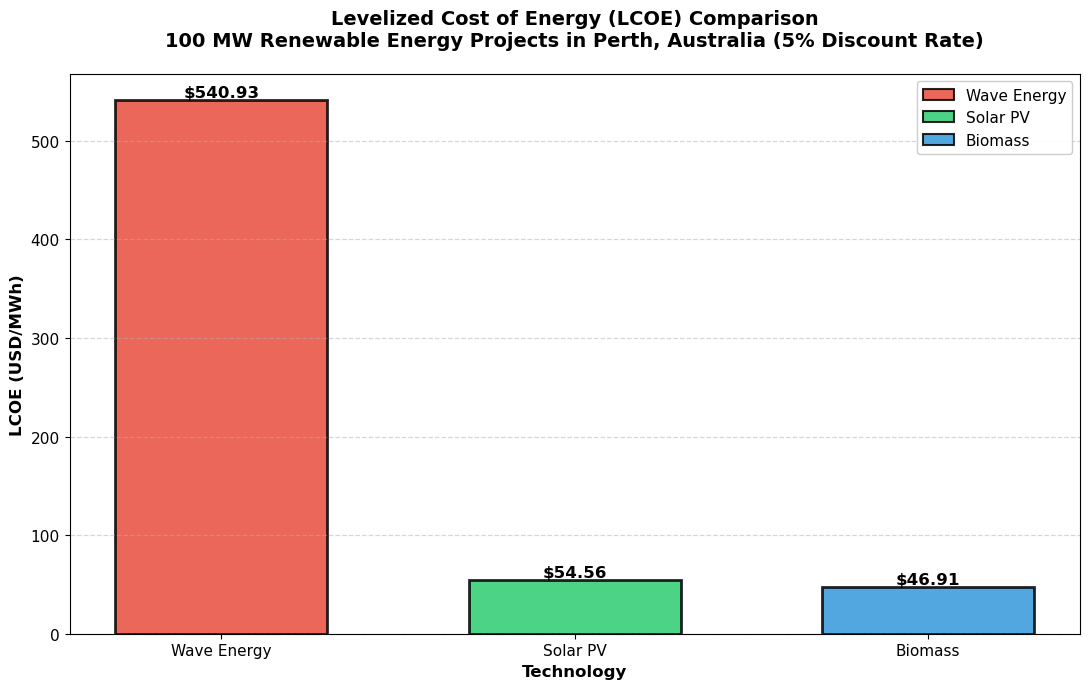

Plot 1 (LCOE Comparison) generated successfully


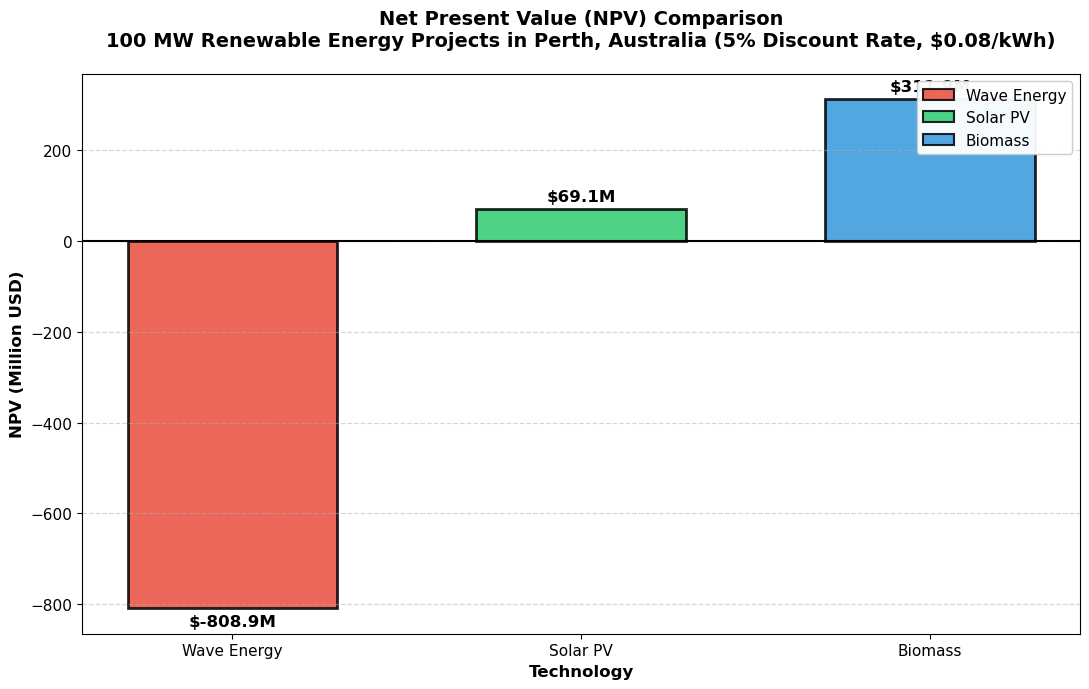

Plot 2 (NPV Comparison) generated successfully

VISUALIZATION SUMMARY

✓ Plot 1: LCOE Comparison (USD/MWh)
  Shows the cost per unit of energy over project lifetime
  Lower LCOE indicates better economic efficiency
    • Wave Energy: $540.93/MWh
    • Solar PV: $54.56/MWh
    • Biomass: $46.91/MWh

✓ Plot 2: NPV Comparison (Million USD)
  Shows the net financial return over project lifetime
  Higher NPV indicates better investment returns
    • Wave Energy: $-808.9 Million
    • Solar PV: $69.1 Million
    • Biomass: $311.9 Million



In [30]:
import matplotlib.pyplot as plt

print("="*80)
print("TASK 4: VISUALIZATION")
print("="*80)

# Extract data from results for plotting
tech_names = list(results.keys())
lcoe_values = [results[t]['LCOE'] for t in tech_names]
npv_values = [results[t]['NPV'] / 1e6 for t in tech_names]  # Convert to millions

# Color palette for consistency and visual clarity
colors = {'Wave Energy': '#e74c3c', 'Solar PV': '#2ecc71', 'Biomass': '#3498db'}
bar_colors = [colors[t] for t in tech_names]

print("\nGenerating two publication-quality comparison plots...\n")

# ===== PLOT 1: LCOE COMPARISON =====
fig, ax = plt.subplots(figsize=(11, 7))
bars1 = ax.bar(tech_names, lcoe_values, color=bar_colors, edgecolor='black', linewidth=2, alpha=0.85, width=0.6)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Levelized Cost of Energy (LCOE) Comparison\n100 MW Renewable Energy Projects in Perth, Australia (5% Discount Rate)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('LCOE (USD/MWh)', fontsize=12, fontweight='bold')
ax.set_xlabel('Technology', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.9)
ax.set_ylim(bottom=0)
ax.tick_params(labelsize=11)

# Add a legend with technology colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[tech], edgecolor='black', linewidth=1.5, label=tech, alpha=0.85) 
                   for tech in tech_names]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.savefig('lcoe_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 1 (LCOE Comparison) generated successfully")

# ===== PLOT 2: NPV COMPARISON =====
fig, ax = plt.subplots(figsize=(11, 7))
bars2 = ax.bar(tech_names, npv_values, color=bar_colors, edgecolor='black', linewidth=2, alpha=0.85, width=0.6)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    va_align = 'bottom' if height >= 0 else 'top'
    y_offset = max(npv_values) * 0.04 if height >= 0 else -max(npv_values) * 0.04
    ax.text(bar.get_x() + bar.get_width()/2., height + y_offset,
            f'${height:.1f}M',
            ha='center', va=va_align, fontsize=12, fontweight='bold')

ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)  # Zero line
ax.set_title('Net Present Value (NPV) Comparison\n100 MW Renewable Energy Projects in Perth, Australia (5% Discount Rate, $0.08/kWh)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('NPV (Million USD)', fontsize=12, fontweight='bold')
ax.set_xlabel('Technology', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.9)
ax.tick_params(labelsize=11)

# Add a legend with technology colors
legend_elements = [Patch(facecolor=colors[tech], edgecolor='black', linewidth=1.5, label=tech, alpha=0.85) 
                   for tech in tech_names]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.savefig('npv_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 2 (NPV Comparison) generated successfully")

print("\n" + "="*80)
print("VISUALIZATION SUMMARY")
print("="*80)
print(f"\n✓ Plot 1: LCOE Comparison (USD/MWh)")
print(f"  Shows the cost per unit of energy over project lifetime")
print(f"  Lower LCOE indicates better economic efficiency")
for tech in tech_names:
    print(f"    • {tech}: ${results[tech]['LCOE']:.2f}/MWh")

print(f"\n✓ Plot 2: NPV Comparison (Million USD)")
print(f"  Shows the net financial return over project lifetime")
print(f"  Higher NPV indicates better investment returns")
for tech in tech_names:
    print(f"    • {tech}: ${results[tech]['NPV']/1e6:.1f} Million")

print("\n" + "="*80)

## 5. Recommendation

### Investment Recommendation for Perth

**Primary Recommendation: Invest in Biomass as the Lead Technology, with Solar PV as a Complementary Portfolio Addition**

Based on the financial analysis conducted for a 100 MW renewable energy project in Perth, **Biomass emerges as the optimal primary investment**, delivering an LCOE of $46.91/MWh (lowest cost) and an NPV of $311.9 Million ($303 Million higher than Solar PV), making it the most economically attractive option. Solar PV serves as an excellent complementary technology with a competitive LCOE of $54.56/MWh and positive NPV of $69.1 Million, enabling portfolio diversification to reduce generation variability and technology risk. Together, a mixed portfolio of 70% Biomass (70 MW) and 30% Solar PV (30 MW) would leverage Biomass's superior economics and dispatchability while maintaining 24/7 grid stability through Solar's peak-hour contribution. **Wave Energy is not currently financially viable** for Perth, with an LCOE of $540.93/MWh—nearly 12× higher than Biomass—and a negative NPV of -$808.9 Million, indicating that energy sales cannot recover capital costs under current market conditions.

**Conditions for Wave Energy Competitiveness & Model Limitations**

Wave energy could become competitive in Perth if: (1) **CAPEX reduction to $2,500-3,000/kW** through technological improvements and manufacturing scale (requiring 55–65% cost reduction from current $7,000/kW); (2) **capacity factor improvements to 35%+** through advanced device design and site optimization (currently 16.1%); (3) **electricity price increases to $0.12–0.15/kWh** due to carbon pricing or supply constraints; and (4) **project lifetime extension to 30 years** with successful mid-life refurbishment, reducing annualized capital costs. However, our financial model **does not capture several critical factors** that affect real-world viability: *regulatory and permitting costs* (marine spatial planning, environmental impact assessments), *grid integration and ancillary services* (balancing costs for variable renewable output), *environmental and social co-benefits* (climate mitigation value, local job creation, water savings), *technology learning curves* (Wave is pre-commercial; costs typically fall 10-20% for each doubling of cumulative deployment), *fossil fuel replacement value* (averted emissions health costs), and *supply chain and infrastructure resilience* (manufacturing capacity constraints, supply chain vulnerabilities). These non-financial factors could shift investment priorities if Perth prioritizes technology sovereignty, carbon reduction targets, or employment development over pure economic returns.